# Data Mining 2026  — Project Notebook

**Course:** Data Mining  
**Project track:** Standard Analysis 
**Group members:**  
- Augustas Butenas
- Adrian Nathanael Christantyo
- Ana-Maria Rusnac
- Bora Tarlan

**Dataset:**  <br>
The dataset to be explored in this project is the Gowalla dataset, found at the [source](https://snap.stanford.edu/data/loc-Gowalla.html). Gowalla is a location-based social networking website where users built friendship networks and shared their locations through check-ins. The friendship network is represented by an undirected graph, consisting of 196,591 nodes and 950,327 edges. Additionally, it includes 6,442,890 check-ins made by users withing the period Feb 2009 - Oct 2010. Each check-in contains spatial and temporal information.

**Initial task description (Module 1 perspective):** <br>
Before applying any algorithms the validity of the data must be checked. For further analysis it might be useful to know if the friendship graph is connected \ find the connected subgraphs. Secondly, a map of the coordinates can be created. With this it easy to see some outlier check-ins. Secondly, we'd see how large the area of observation is. If it is large enough it might be a good idea to find observation clusters, and in that way we can avoid accounting for the "looping" of coordinates. Furthermore, in order to catch some nonsense data a couple of things can be done: 1. for same location IDs check if the coordinates are similar; 2. For same person check ins that are near in time does it seem that seem like they teleported.
 
In the context of clustering, some of the main tasks would be hierarchical and subspace clustering of user check-in locations. The goal is to provide an analysis on spatial behaviour at multiple scales, for example multiple clusters could represent a street, a neighbourhood, or a city. Based on these scales behaviours can be compared as well, most importantly if different users or communities are similar in distinct subspaces. 

Another point would be hierarchical friend groups, groups at different scales may correspond to one-off meetings, distant friends to close friends and family. Thus, inference of relationships could also be accomplished, the frequency of 2 people checking in at the same time might suggest social ties. Using the same train of thought, the model could even suggest possible friendships if 2 people meeting frequently or occasionally are not already friends according to the graph.

A second focus point would be community detection and sequence segmentation and similarities. The goal is to identify groups of users that are densely connected and analyse if there are mobility patterns based on check in locations. In this case, user check ins are treated as temporal movement sequences. Multiple interesting questions can be explored, such as if the behaviour similarity is based on movement sequence rather than relation and which are the most common routes.

Lastly, a potential focus could be location labeling based on visiting frequency and time, for example, a place that is visited very often by a single person can be labeled as a home location. On the other hand, a place that is primarily visited in the evening by groups of friends might be labeled as night-leisure location. 


## 0. Reproducibility and Setup

In [ ]:

import sys
print(sys.version)

import pandas as pd
import numpy as np
import seaborn as sns            
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from shapely.geometry import Point
import geopandas as gpd
from pathlib import Path
import reverse_geocoder as rg
import country_converter as coco
from tabulate import tabulate
from pygal_maps_world.maps import World
from pygal.style import Style, SaturateStyle
from IPython.display import SVG
from sklearn.cluster import DBSCAN
import hdbscan
from sklearn.cluster import OPTICS
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import haversine_distances
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import math
import datashader as ds
import datashader.transfer_functions as tf
from datashader.layout import circular_layout
from datashader.bundling import connect_edges, hammer_bundle

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


## 1. Dataset Description and Loading

### 1.1 Dataset Overview

The dataset used in this project is the dataset collected by Gowalla, a location-based social networking platform, from February 2009 - October 2010. The dataset was collected and uploaded to Stanford Network Analysis Project (SNAP). There are 6.442.892 instances of check-ins made by users around the world during that time period. The dataset consists of 5 columns: user ID, check-in time, latitude, longitude, and location ID.

In [2]:
# Load dataset
BASE_DIR = Path().resolve()
file_path = BASE_DIR / "data" / "loc-gowalla_totalCheckins.txt"

df = pd.read_csv(file_path, sep = "\t", header = None, names=["user_id", "checkin_time", "latitude", "longitude", "location_id"])

print(df.head(5))
print(df.tail(5))

   user_id          checkin_time   latitude  longitude  location_id
0        0  2010-10-19T23:55:27Z  30.235909 -97.795140        22847
1        0  2010-10-18T22:17:43Z  30.269103 -97.749395       420315
2        0  2010-10-17T23:42:03Z  30.255731 -97.763386       316637
3        0  2010-10-17T19:26:05Z  30.263418 -97.757597        16516
4        0  2010-10-16T18:50:42Z  30.274292 -97.740523      5535878
         user_id          checkin_time   latitude  longitude  location_id
6442887   196578  2010-06-11T13:32:26Z  51.742988  -0.488065       906885
6442888   196578  2010-06-11T13:26:45Z  51.746492  -0.490780       965121
6442889   196578  2010-06-11T13:26:34Z  51.741916  -0.496729      1174322
6442890   196585  2010-10-08T21:01:49Z  50.105516   8.571525       471724
6442891   196585  2010-10-07T17:39:18Z  50.027812   8.785098      4555073


In [3]:
print(df.dtypes)

user_id           int64
checkin_time     object
latitude        float64
longitude       float64
location_id       int64
dtype: object


In [4]:
print("Initial shape of df: ", df.shape)

Initial shape of df:  (6442892, 5)


A second dataset used is the friendship data between users, which consists of 196,591 nodes and 950,327 edges. There are two columns in the dataset: user ID and friend ID.

In [5]:
file_path2 = BASE_DIR / "data" / "loc-gowalla_edges.txt"
df2 = pd.read_csv(file_path2, sep = "\t", header = None, names=["user_id", "friend_id"])
print(df2.head(5))
print(df2.tail(5))

   user_id  friend_id
0        0          1
1        0          2
2        0          3
3        0          4
4        0          5
         user_id  friend_id
1900649   196586     196539
1900650   196587     196540
1900651   196588     196540
1900652   196589     196547
1900653   196590     196561


In [6]:

print("Initial shape of df2: ", df2.shape)

Initial shape of df2:  (1900654, 2)


### 1.2 Cleaning & Transformations

The first step of the data cleaning process is to check and remove duplicates, as well as check and handle missing values.

In [7]:
print("Initial shape of df:", df.shape)

duplicates = df[df.duplicated()]
print("number of duplicate rows:", duplicates.shape[0], "\n", duplicates)

df = df.drop_duplicates()
print("Shape of df after removal of duplicates:", df.shape)


Initial shape of df: (6442892, 5)
number of duplicate rows: 601 
          user_id          checkin_time   latitude   longitude  location_id
17780         94  2009-08-17T01:31:47Z  32.897642  -97.044339         9197
17788         94  2009-07-17T17:07:10Z  32.894526  -97.256234        13976
30684        130  2009-07-22T04:01:34Z  37.760350 -122.504984        18126
30752        130  2009-04-13T01:14:43Z  37.779271 -122.419238         9152
33378        138  2009-07-15T17:35:24Z  32.945454  -97.129183        11604
...          ...                   ...        ...         ...          ...
6408672   190424  2010-10-04T14:17:00Z  51.576336   -0.224533       524355
6417055   191980  2010-06-01T12:36:48Z  59.272065   15.229156       902263
6418387   192241  2010-04-11T13:07:08Z  57.781784   14.170381       164115
6418388   192241  2010-04-11T13:07:08Z  57.781784   14.170381       164115
6418525   192257  2010-03-08T14:12:32Z  50.577321   10.426133       664937

[601 rows x 5 columns]
Shape of d

In [8]:
print("The number of null entries: \n", df.isnull().sum())

The number of null entries: 
 user_id         0
checkin_time    0
latitude        0
longitude       0
location_id     0
dtype: int64


From this we observe that there are 601 duplicate values and 0 missing values. The duplicate values are likely due to the inaccuracies in the Gowalla app during the recording of the data, and therefore are removed. Since there is no missing values present in the data, no additional missing value handling is necessary. Next, we check the validity of the data points.

Text(0, 0.5, 'Latitude')

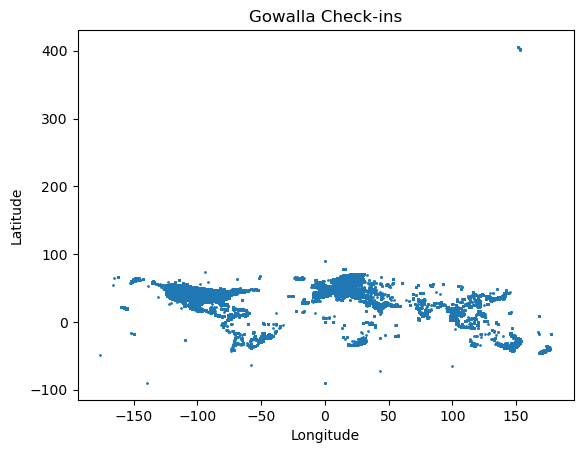

In [9]:
plt.scatter(df["longitude"], df["latitude"], s=1)
plt.title("Gowalla Check-ins")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

The data that we use contains geographic coordinates in the form of latitude and longitude data. Because latitude values are bounded between -90° and 90° (North and South), longitude values are bounded between -180° and 180° (West and East), any values outside these ranges are considered invalid. These observations likely result from data entry or measurement errors and therefore are removed from the dataset.

Text(0, 0.5, 'Latitude')

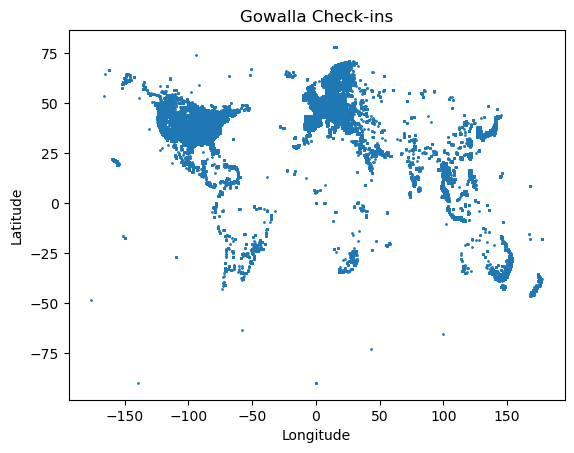

In [10]:
#Removing invalid data points
df = df.drop(df[df['latitude'] >= 90].index)
df = df.drop(df[df['longitude'] >= 180].index)
plt.scatter(df["longitude"], df["latitude"], s=1)
plt.title("Gowalla Check-ins")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

In [11]:
print("Shape of df after data cleaning:", df.shape)

Shape of df after data cleaning: (6442260, 5)


There are now 6.442.260 instances that are valid to use. Second, we transform the data to make sure that each column is stored in the appropriate format for analysis. The check-in time variable is initially stored as an object, which prevents it from being used in time-based operations. Therefore, it is converted into a datetime format, allowing us to properly use the temporal features when needed.


In [12]:
df['checkin_time'] = pd.to_datetime(df['checkin_time'], errors='coerce')
print(df.dtypes)

user_id                       int64
checkin_time    datetime64[ns, UTC]
latitude                    float64
longitude                   float64
location_id                   int64
dtype: object


Lastly, due to the large scale of the data, we introduce additional categorical variables for the names of the city, country, and continent. These additional categorical variables are added to help with future needs in this project.

In [13]:
coordinates = list(zip(df['latitude'], df['longitude']))
result = rg.search(coordinates)

df["city"] = [result[i]['name'] for i in range(len(result))]
df["country_code"] = [result[i]['cc'] for i in range(len(result))]
df["country_code"] = df["country_code"].str.lower() #for pygal

cc = coco.CountryConverter()

mapping = {
    code: cc.convert(code, to="name")
    for code in df["country_code"].unique()
}

continent = {
    code: cc.convert(code, to="continent_7")
    for code in df["country_code"].unique()
}

df["country_name"] = df["country_code"].map(mapping)
df["continent"] = df["country_code"].map(continent)
df.to_csv('data/loc-gowalla-preproc.csv', index=False)
print(df.head())
print(df.tail())

Loading formatted geocoded file...
   user_id              checkin_time   latitude  longitude  location_id  \
0        0 2010-10-19 23:55:27+00:00  30.235909 -97.795140        22847   
1        0 2010-10-18 22:17:43+00:00  30.269103 -97.749395       420315   
2        0 2010-10-17 23:42:03+00:00  30.255731 -97.763386       316637   
3        0 2010-10-17 19:26:05+00:00  30.263418 -97.757597        16516   
4        0 2010-10-16 18:50:42+00:00  30.274292 -97.740523      5535878   

          city country_code   country_name      continent  
0  Rollingwood           us  United States  North America  
1       Austin           us  United States  North America  
2       Austin           us  United States  North America  
3       Austin           us  United States  North America  
4       Austin           us  United States  North America  
         user_id              checkin_time   latitude  longitude  location_id  \
6442887   196578 2010-06-11 13:32:26+00:00  51.742988  -0.488065       90

A note to add to this is that ```reverse_geocoder``` uses the latitude and longitude of the data and finds the nearest town/city. This means that the values returned are an approximate representation of the location. Other more accurate methods of this same process were attempted using ```geopandas``` and ```geopy``` libraries, but due to the amount of data we had, the process took longer than anticipated. Thus ```reverse_geocoder``` was used instead.

### 1.3 Exploratory Data Analysis

In this step, we find the basic statistics of the dataset. First we find the count and distribution of the data points.

In [14]:
continent_counts = df["continent"].value_counts()
print(tabulate(continent_counts.items(), headers=["Continent", "Count"], tablefmt="grid"))

+---------------+---------+
| Continent     |   Count |
+===============+=========+
| North America | 3796400 |
+---------------+---------+
| Europe        | 2201022 |
+---------------+---------+
| Asia          |  341005 |
+---------------+---------+
| Oceania       |   69434 |
+---------------+---------+
| South America |   19889 |
+---------------+---------+
| Africa        |   14508 |
+---------------+---------+
| Antarctica    |       2 |
+---------------+---------+


In [15]:
country_counts = df["country_name"].value_counts()
preview = list(country_counts.head().items())+ [("...", "...")]+ list(country_counts.tail().items())
print(tabulate(preview, headers=["Country Name", "Check-in Count"]))

Country Name      Check-in Count
----------------  ----------------
United States     3615082
Sweden            926787
Germany           349897
United Kingdom    272881
Norway            154534
...               ...
Malawi            1
Christmas Island  1
North Korea       1
Mali              1
Guadeloupe        1


From the two outputs above, we can see that the majority of the instances in the continent context are North America and Europe (3.796.400 and 2.201.022 instances respectively). The majority of the instances in the country context are United States (3.615.082 instances), Sweden (926.787 instances), Germany (349.897 instances), United Kingdom (272.881 instances), and Norway (154.534 instances). Below is a map to better show the distribution of the instances across the world.

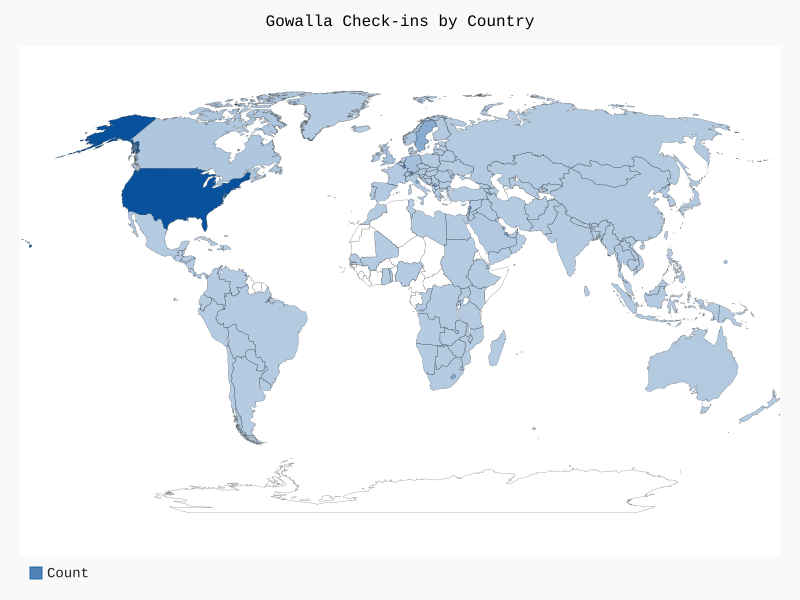

In [16]:
custom_style = SaturateStyle('#08519c',step = 10)

count_country = df["country_code"].value_counts().to_dict()

worldmap = World(style = custom_style)
worldmap.title = "Gowalla Check-ins by Country"
worldmap.add('Count', {
    country_code: count for country_code, count in count_country.items() if country_code is not None
})

SVG(worldmap.render(legend_at_bottom=True))

Next, we will see the basic statistics of the dataset. Due to the large scale of the dataset, our two main continents that will be put into discussion are **North America** and **Europe**.

#### North America
From the North America data points, we can find the mean of the latitude and longitude.

In [17]:
print("Descriptive Statistics for North America:")
print(df[df["continent"] == "North America"][["latitude","longitude"]].describe())

Descriptive Statistics for North America:
           latitude     longitude
count  3.796400e+06  3.796400e+06
mean   3.617323e+01 -9.764598e+01
std    5.942494e+00  1.815472e+01
min    7.924612e+00 -1.665249e+02
25%    3.275401e+01 -1.162914e+02
50%    3.606905e+01 -9.680944e+01
75%    4.024569e+01 -8.250047e+01
max    7.406970e+01 -5.069384e+01


From this, we obtain the mean of the latitude and longitude in North America being **(36.17323,-97.64598)**. The visualization below shows a better depiction of the mean in the North America continent. The red dot represents the mean of the data in the North America continent.

Text(0, 0.5, 'Latitude')

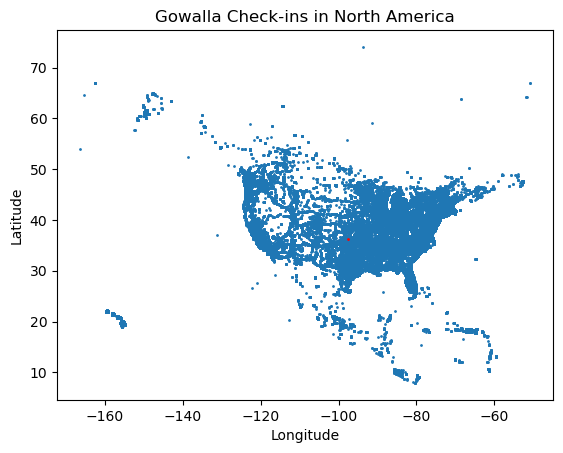

In [18]:
plt.scatter(df[df["continent"] == "North America"]["longitude"], df[df["continent"] == "North America"]["latitude"], s=1, label="North America")
plt.plot(df[df["continent"] == "North America"]["longitude"].mean(), df[df["continent"] == "North America"]["latitude"].mean(), 'o', c="red", markersize=1, label="North America")
plt.title("Gowalla Check-ins in North America")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

#### Europe
From the Europe data points, we can find the mean of the latitude and longitude.

In [19]:
print("\n Descriptive Statistics for Europe:")
print(df[df["continent"] == "Europe"][["latitude","longitude"]].describe())


 Descriptive Statistics for Europe:
           latitude     longitude
count  2.201022e+06  2.201022e+06
mean   5.444710e+01  1.050813e+01
std    5.352545e+00  7.242627e+00
min    2.773498e+01 -2.854111e+01
25%    5.106067e+01  6.491379e+00
50%    5.559659e+01  1.194992e+01
75%    5.931550e+01  1.660823e+01
max    7.827639e+01  1.420488e+02


From this, we obtain the mean of the latitude and longitude in Europe being **(54.4471, 10.50813)**. The visualization below shows a better depiction of the mean in the Europe continent. The red dot represents the mean of the data in the Europe continent.

Text(0, 0.5, 'Latitude')

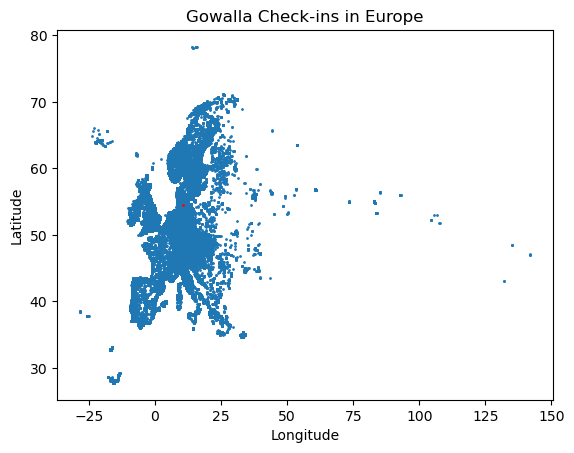

In [20]:
plt.scatter(df[df["continent"] == "Europe"]["longitude"], df[df["continent"] == "Europe"]["latitude"], s=1, label="Europe")
plt.plot(df[df["continent"] == "Europe"]["longitude"].mean(), df[df["continent"] == "Europe"]["latitude"].mean(), 'o', c="red", markersize=1, label="Europe")
plt.title("Gowalla Check-ins in Europe")
plt.xlabel("Longitude")
plt.ylabel("Latitude")


Next, we look at distribution of the check-ins across the timeline of February 2009 until October 2010.

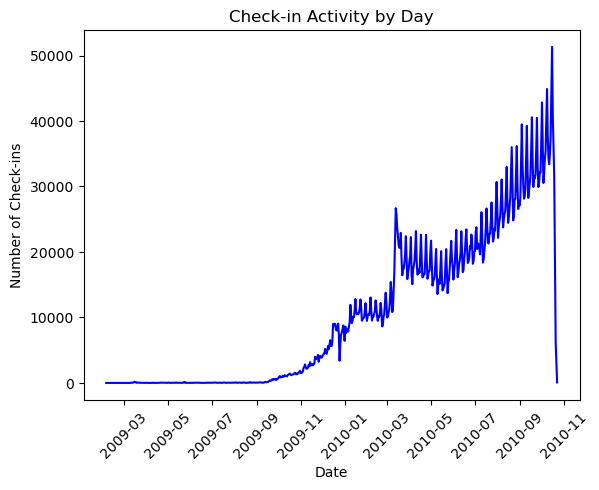

In [21]:
plt.figure()
plt.plot(df['checkin_time'].dt.date.sort_values().unique(), df['checkin_time'].dt.date.value_counts().sort_index(), color="blue")
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Number of Check-ins")
plt.title("Check-in Activity by Day")
plt.show()

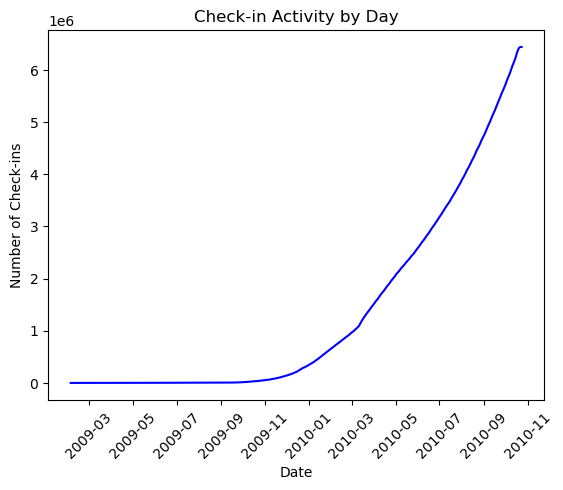

In [22]:
plt.figure()
plt.plot(df['checkin_time'].dt.date.sort_values().unique(), df['checkin_time'].dt.date.value_counts().sort_index().cumsum(), color="blue")
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Number of Check-ins")
plt.title("Check-in Activity by Day")
plt.show()

From the two charts above, we can see that the majority of the check-ins started to increase in number around the start of 2010. The number increased from less than 10.000 instances per day to around 20.000 to 40.000 instances per day. 

### 1.4 Graph Construction

For the second checkpoint onwards, we would need to construct a graph. A part of the Gowalla dataset is the friendship network. The friendship network is represented by an undirected graph, consisting of 196,591 nodes and 950,327 edges. Due to the large amount of edges, we divide the nodes and edges per continent, mainly focusing on users that have the majority of their check-ins in **Europe**.

First, we conduct data cleaning by checking for duplicates and missing values.

In [23]:
print(df2.duplicated().sum())
print(df2.isna().sum())
print(df2.nunique())

0
user_id      0
friend_id    0
dtype: int64
user_id      196591
friend_id    196591
dtype: int64


Next, using the dataset of check-ins, we can categorize each user according to continent by highest amount of check-ins for each user.

In [24]:
counts = df.groupby(['user_id','continent']).size().reset_index(name="checkin_count").sort_values(by='user_id', ascending=True)
results = []
for user_id in counts['user_id'].unique():
    top_continent = counts[counts['user_id'] == user_id].sort_values(by='checkin_count', ascending=False).iloc[0]['continent']
    results.append((user_id, top_continent))
results = pd.DataFrame(results, columns=["user_id", "continent"])
df2 = df2.merge(results.rename(columns={'continent': 'user_continent'}), on="user_id", how="left")
df2 = df2.merge(results.rename(columns={'continent': 'friend_continent'}), left_on="friend_id", right_on="user_id", how="left")
df2 = df2.drop(columns=["user_id_y"])
df2.rename(columns={"user_id_x" : "user_id"}, inplace=True)
print(df2.head())


   user_id  friend_id user_continent friend_continent
0        0          1  North America           Europe
1        0          2  North America    North America
2        0          3  North America              NaN
3        0          4  North America    North America
4        0          5  North America    North America


Since some users return a **NaN** output, we remove these rows for better results.

In [ ]:
df2.dropna(inplace=True)

In [38]:
df2_eu = df2[(df2['user_continent'] == "Europe")]
sample = df2_eu.sample(n=100, random_state=RANDOM_SEED)
sample2 = df2_eu.groupby(['user_id'], as_index=False, group_keys=False).apply(lambda x: x.sample(min(3,len(x)), random_state=RANDOM_SEED)).reset_index(drop=True)
print(sample2.shape)

(96692, 4)


C:\Users\Adrian\AppData\Local\Temp\ipykernel_39660\3179957298.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample2 = df2_eu.groupby(['user_id'], as_index=False, group_keys=False).apply(lambda x: x.sample(min(3,len(x)), random_state=RANDOM_SEED)).reset_index(drop=True)


In [49]:
nodes = pd.DataFrame(["node" + str(i) for i in df2_eu['user_id'].unique()], columns=["name"])
edges = pd.DataFrame(df2_eu[['user_id', 'friend_id']].values.tolist(), columns=["source", "target"])
print(nodes.head())
print(edges.tail())

      name
0    node1
1   node67
2   node72
3   node99
4  node100
        source  target
330846  196489  196488
330847  196494  196033
330848  196500  196100
330849  196508  196109
330850  196520    4727


In [50]:
cvsopts = dict(plot_height=500, plot_width=500)

def nodesplot(nodes, name=None, canvas=None, cat=None):
    canvas = ds.Canvas(**cvsopts) if canvas is None else canvas
    aggregator=None if cat is None else ds.count_cat(cat)
    agg=canvas.points(nodes,'x','y',aggregator)
    return tf.spread(tf.shade(agg, cmap=["#FF3333"]), px=3, name=name)

circular  = circular_layout(nodes, uniform=False)
def nodesplot(nodes, name=None, canvas=None, cat=None):
    canvas = ds.Canvas(**cvsopts) if canvas is None else canvas
    aggregator=None if cat is None else ds.count_cat(cat)
    agg=canvas.points(nodes,'x','y',aggregator)
    return tf.spread(tf.shade(agg, cmap=["#FF3333"]), px=1, name=name)

def edgesplot(edges, name=None, canvas=None):
    canvas = ds.Canvas(**cvsopts) if canvas is None else canvas
    return tf.shade(canvas.line(edges, 'x','y', agg=ds.count()), name=name)

def graphplot(nodes, edges, name="", canvas=None, cat=None):
    if canvas is None:
        xr = nodes.x.min(), nodes.x.max()
        yr = nodes.y.min(), nodes.y.max()
        canvas = ds.Canvas(x_range=xr, y_range=yr, **cvsopts)

    np = nodesplot(nodes, name + " nodes", canvas, cat)
    ep = edgesplot(edges, name + " edges", canvas)
    return tf.stack(ep, np, how="over", name=name)


CPU times: total: 266 ms
Wall time: 287 ms
CPU times: total: 1min 2s
Wall time: 1min 3s


Circular layout,"Circular layout, bundled"

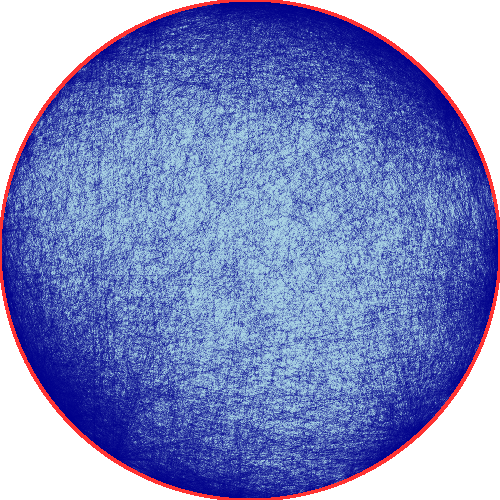
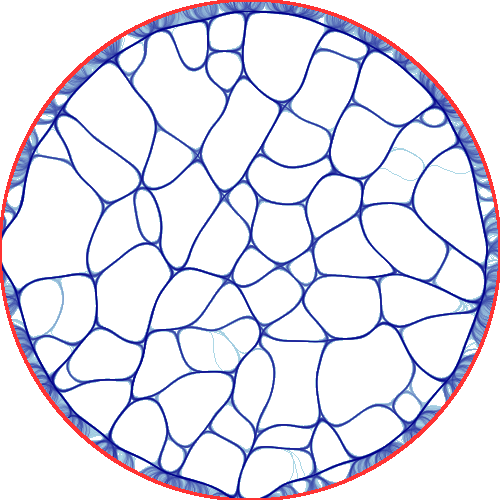

In [51]:
cd = circular

%time cd_d = graphplot(cd, connect_edges(cd,edges), "Circular layout")
%time cd_b = graphplot(cd, hammer_bundle(cd,edges), "Circular layout, bundled")

tf.Images(cd_d,cd_b)

Clustering with DBSCAN one country at a time and comparison. (https://geoffboeing.com/2014/08/clustering-to-reduce-spatial-data-set-size/)
The UK:

## 2. Module 1 — Vector-Space Analysis

### 2.1 Vector Representation
In this project, there are 3 different features, which are check-in time, latitude, and longitude. The check-in time is stored as a date and time with the format of "YYYY-MM-DD HH:MM:SS". The latitude and longitude are geographic coordinates, with latitude values bounded between -90° and 90° and longitude values bounded between -180° and 180°.

### 2.2 Clustering Method

#### 2.2.1 DBscan Clustering

The main part of this clustering is to find out what points fall under the same sensible "activity hub" and if we can see anything intersting. Later on it will be interesting to see if the same people belonging to specific sets of actvity clusters are also part of the same community in the graph data. Lastly as a consequence of grouping things into hubs we will be able to find outliers (noise) which will be places that have very few other locations around them.

Clustring DBscan for activity hubs

The motivation for choosing DBscan is:
1) We do not need to choose cluster number a priori for which DBscan works
2) We don't need to specify the cluster shape.
3) Handle differnece in distributions. Here DBscan might fail.

As we have a lot of data points (more than the machine that ran DBscan can handle), we will split the world into two - Left (Americas) and right (Everything else). We eyeball the split at longitude = -30 which is around the middle of the atlantic ocean. As mentioned before it needs to be checked if the split is nto accidentally breaking a potential cluster into two. This can be seen by simply looking at the map - no points in the middle or very near the split.

In [21]:
# Split the world into 2
df_left  = df[df["longitude"] < -30]  
df_right = df[df["longitude"] >= -30] 

print(len(df_left), "on the left")
print(len(df_right), "on the right")

3816306 on the left
2625954 on the right


In [22]:
# Merge same locations by ID
df_left_unique_id = df_left.drop_duplicates(subset=["location_id"])
df_right_unique_id = df_right.drop_duplicates(subset=["location_id"])

del df_left
del df_right
 
print(len(df_left_unique_id), " on the left")
print(len(df_right_unique_id), " on the right")

# And we know that we should get the same as num of unique ID before the split 
# Else the same ID is used on the left and right side of the worldd
print(len(df.drop_duplicates(subset=["location_id"])) - len(df_right_unique_id) - len(df_left_unique_id), " the differnece between origina and splits num of unique ID")

712101  on the left
568854  on the right
0  the differnece between origina and splits num of unique ID


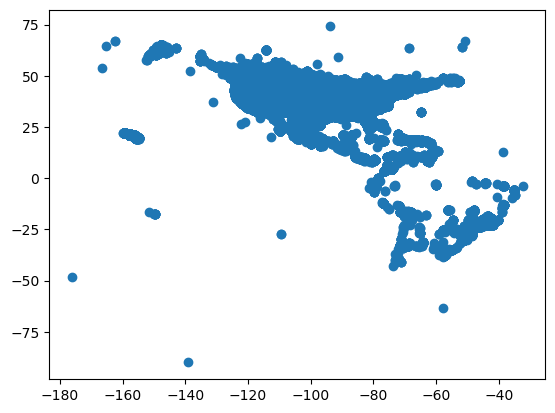

In [23]:
# Map of the left side
plt.scatter(df_left_unique_id["longitude"], df_left_unique_id["latitude"], )

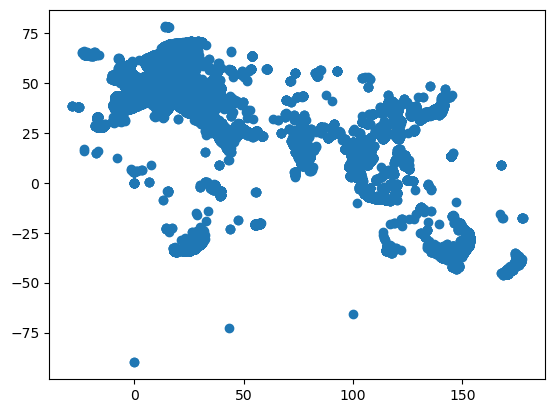

In [24]:
# Map of the right side
plt.scatter(df_right_unique_id["longitude"], df_right_unique_id["latitude"], )

Now the two main problem are 
- how to handle the still large amount of points
- what epsilon to choose

The min_samples for core point is chosen as dimension * 2 - 1 = 3. Choosing any higher makes little sense as choosing too high will make small hubs be marked as noise. 

As seen above even after splitting the world in two we still too many points to be able to run the method especially as epsilon increases. We propose a following work around:

1. Cut up the space into (at least) espilon-overlapping regions.
2. Run DBSCAN for each region
3. If we have a core point in the border region it gives connection between the two regions.

If the overlap was smaller than epsilon we might loose out on points that make a point in our non-overallping reagion into a core point, thus we would loose the nice way to join border clusters. If it were bigger in theory we would not gain any extra information but in code we might not loose points due to rounding errors.

For a choice of epsilon the elbow method is attempted. We know that one degree change is approximately (decreaes the further from equator we go) 111km change in distance - this only gives a rough understanding on the scale of epsilon. As here we are trying to find the main hubs we should avoid picking small epsilon as it might produce a lot tiny clusters. Yet if we pick larger eps, for example even epsilon = 2, as metioned before we face a memory problem as we have a lot of dense areas (for each neighborhood we have to check a large amount of points) and we will only have big, non infromative clusters. 

Potential TODO Later on we will do clustering with two distance functions: Euclidean and Haversine, which is the distance is the angular distance between two points on the surface of a sphere.

##### Elbow method. K-nearest Neighbors

Text(0, 0.5, '3rd Nearest Neighbor Distance')

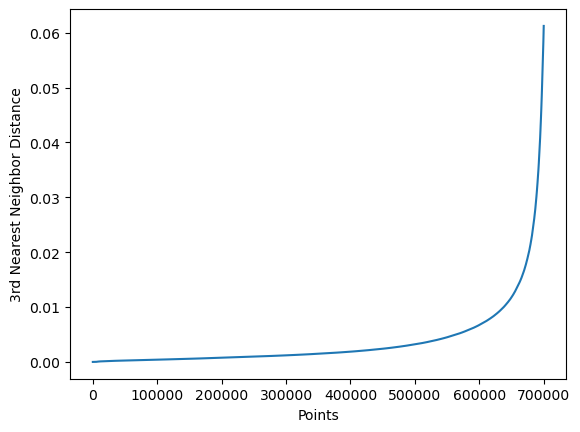

In [27]:
# elbow method in euclidean. 
temp_data = df_left_unique_id[["latitude", "longitude"]]
nbrs = NearestNeighbors(n_neighbors=3+1, metric="euclidean").fit(temp_data)
distances, indices = nbrs.kneighbors(temp_data)
distances = np.sort(distances[:, 3])
plt.plot(distances[0:700000]) # As plotting all points is not informative due to some points being very far away from anothers
plt.xlabel('Points')
plt.ylabel('3rd Nearest Neighbor Distance')

Text(0, 0.5, '3rd Nearest Neighbor Distance')

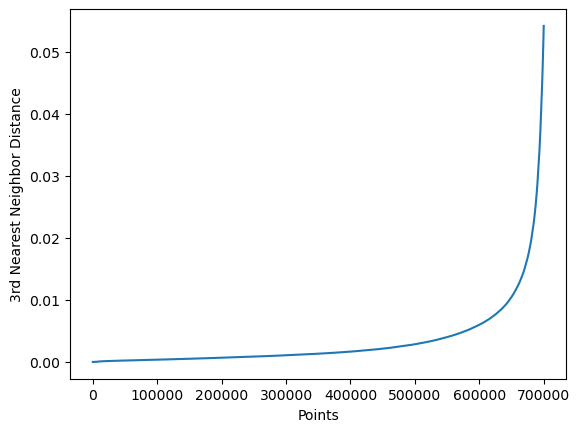

In [28]:
# elbow method In Haversine. The distance is more correct than using euclidean due to the data being on a spehere.
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.haversine_distances.html

df_left_unique_id['latitude_rad'] = np.radians(df['latitude'])
df_left_unique_id['longitude_rad'] = np.radians(df['longitude'])

temp_data = df_left_unique_id[["latitude_rad", "longitude_rad"]]
nbrs = NearestNeighbors(n_neighbors=3+1, metric="haversine").fit(temp_data) # n = itself + n-1 next neighbors
distances, indices = nbrs.kneighbors(temp_data)
distances = np.sort(distances[:, 3])
plt.plot(np.degrees(distances[0:700000])) # Back into degrees
plt.xlabel('Points')
plt.ylabel('3rd Nearest Neighbor Distance')

And here we see that most points are densly packed. The graphs suggests to pick epsilon around 0.01.

Another question that worthy thinking of is if Haversine is really needed here or can we accept the innacuracy of using Euclidean especially as we are not working on the whole world but only parts of it at a single time. For now we cluster with just euclidean metric.

##### Left world clustering 

In [29]:
# We split the area into two with chosen epsilon
epsilon_elbow = 0.01

# Splitting the left side into two manageable reagions. The -90 was chosen by looking at the map and trying to split it to be around 50/50
df_left_left = df_left_unique_id[df_left_unique_id["longitude"] <= -90 + epsilon_elbow][["latitude", "longitude"]] 
df_left_right = df_left_unique_id[df_left_unique_id["longitude"] >= -90 - epsilon_elbow][["latitude", "longitude"]] 

# Here we notice that overlapping region is 2*epsilon. For now we accpet it.
# For very dense regions it might be problematic.
print(len(df_left_left), "points in left region")
print(len(df_left_right), "points in right region")

379059 points in left region
333336 points in right region


In [30]:
# Defining a clustring function. We only need lables and core points.

def DBSCAN_clusterin(clustering_data, epsilon, min_points = 3, metric = "euclidean"):
    clustering= DBSCAN(eps=epsilon, min_samples=min_points, metric=metric).fit(clustering_data)

    # We get this amount of clusters - noise
    print(len(set(clustering.labels_)) - (1 if -1 in clustering.labels_ else 0), "clusters not incl noise")
    print(np.sum(clustering.labels_ == -1), "points of noise")
    print((np.sum(clustering.labels_ == -1)/len(clustering_data)*100).round(2), "% of data is noise")

    labels = clustering.labels_
    cores_points = clustering.core_sample_indices_

    del clustering
    return labels , cores_points


In [31]:
labels, core_samples = DBSCAN_clusterin(df_left_left[["latitude", "longitude"]], epsilon_elbow)

5990 clusters not incl noise
20432 points of noise
5.39 % of data is noise


In [32]:
labels, core_samples = DBSCAN_clusterin(df_left_right[["latitude", "longitude"]], epsilon_elbow)

8844 clusters not incl noise
27690 points of noise
8.31 % of data is noise


Even without proper merging of the two overlapping regions into one we can see that for epsilon = 0.01 we get a massive amount of clusters. That is to be expceted as with the elbow method we are seeing what distance works for most points to be a core point and the "elbow" can be interpreted as points that are further away than most i.e. noise but we already knew our points are dense so at best this epsilon gives very local hubs and the result is interpretable.

Thus let's try increasing epsilon to 0.3 and then to 1 to see if the clusters become sensible.

In [33]:
# We split the area into two with chosen epsilon
epsilon = 0.3 

# Splitting the left side into two manageable reagions. The -90 was chosen by looking at the map and trying to split it to be around 50/50
df_left_left = df_left_unique_id[df_left_unique_id["longitude"] <= -93 + epsilon][["latitude", "longitude"]] 
df_left_right = df_left_unique_id[df_left_unique_id["longitude"] >= -93 - epsilon][["latitude", "longitude"]] 

# Here we notice that overlapping region is 2*epsilon. But that is fine because as the goal was to reduce points to sub 400000.

print(len(df_left_left), "points in left region")
print(len(df_left_right), "points in right region")

359304 points in left region
361542 points in right region


In [34]:
labels_left, core_samples_left = DBSCAN_clusterin(df_left_left[["latitude", "longitude"]], epsilon)

403 clusters not incl noise
392 points of noise
0.11 % of data is noise


In [35]:
labels_right, core_samples_right = DBSCAN_clusterin(df_left_right[["latitude", "longitude"]], epsilon)

241 clusters not incl noise
285 points of noise
0.08 % of data is noise


Once again - too many clusters. Yet let's merge these two regions and create noise point scatterplot.
The idea on how to merge these two regions is for a point that is in a left region cluster and in a right region cluster we hold that these two cluster are the same if x is a core point in at least one of the clusters. Notice that in this way multiple left - right region clusters could be joined into one i.e. 1 to 1 mapping is not guaranteed.

In [36]:
# Function that creates the mapping
def create_mapping(left_data, left_label, left_core, right_data, right_label, right_core, push = 0):
    # We find which points the splits share
    shared_points = left_data.index.intersection(right_data.index) 
    print(len(shared_points), " num of shared points")

    if push == 0: # Defualt value for push variable.
        push = len(set(left_label))


    # Nudge the labeling so that labess would be unique
    unique_labels_right = np.where(
        right_label == -1, 
        -1, 
        right_label + push # the nudge
    )

    # For every point we check if it is core in one of the splits
    # If it is core then we find how to map clusters. 
    # Although won't necessarily get 1 to 1 mapping so the relabeling part is not trivial

    mappings = []

    for i in shared_points:

        # We need this because our index in the dataframe don't match up with index we get via DBSCAN
        # Here even if two differnet locations share the same postion it does not matter.
        
        position_left = left_data.index.get_loc(i)
        position_right = right_data.index.get_loc(i)

        if position_left in right_core or position_right in left_core: # If point is a core point

            label_left = left_label[position_left]
            label_right = unique_labels_right[position_right]

            if label_left != -1 and label_right != -1: #Just in case tho I'm pretty sure this is not needed.
                mappings += [[label_left, label_right]]

    map = [list(i) for i in set(tuple(m) for m in mappings)] #to remove dupes

    return map, unique_labels_right

In [37]:
# Relabeling. 
# Yes it would've been smarted to do the mapping straight to a dictionary but I didn't think of it at the time. 

def merge_labels(labels_left, labels_right, mappings):
    
    # Instead of list of lists we'll work with a dictionary
    connection_graph = {}
    all_labels = set(np.concatenate([labels_left, labels_right]))
    
    if -1 in all_labels: # Noise will stay noise. 
        all_labels.remove(-1)

    for a, b in mappings: 
        connection_graph.setdefault(a, set()).add(b) # for key a we add value b 
        connection_graph.setdefault(b, set()).add(a) # for key b we add value a 

    # Because we we don't have a 1 to 1 mappig we can't just change labels directly
    # So the idea here is to:
    # 1) pick a label
    # 2) check what labels are coonected to it. They are part of same cluster
    # 3) then for each label connected go back to step 1)
    # 4) keep rechecking and keeping track of what we've said to be the same cluster

    visited = set() # Prevents us from counting the same label twice.
    label_map = {} # Maping old label to new label
    
    for label in all_labels:
        if label not in visited:

            component = [] # Everything under this is the "same" label\cluster
            stack = [label] # This is the list of keys for which we have to check the correspondinng values
            visited.add(label) # add that we have checked this. Else we could have an inifite loop
            
            while stack: #While we have things to check for the cluster chain
                current = stack.pop() #The one we are checking
                component.append(current) #We add the "same clusters different labels" list
                for neighbor in connection_graph.get(current, []): # Return [] as default if no connections
                    if neighbor not in visited:
                        visited.add(neighbor)
                        stack.append(neighbor) #loops up to the begging of while and it adds itself to the component there
            
            # Use the smallest label in the group as the new id
            new_id = min(component)
            for item in component:
                label_map[item] = new_id
            # So we end up for each old id a sigle new id


    # A helper function 
    def transform(sequence):
        # And then for each old id if it is not noise we replace it by the new id
        return [label_map.get(label, label) if label != -1 else -1 for label in sequence]

    return transform(labels_left), transform(labels_right)

In [38]:
# Testing exampple
left = [-1, 0, 2 ,1, 2, 5]
right = [-1, 6, 7, 8, 9]
map_list = [[0, 6], [1, 8], [2, 6], [0,9]]

new_left, new_right = merge_labels(left, right, map_list)

print("Updated Left:", new_left)
print("Updated Right:", new_right)

Updated Left: [-1, np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(5)]
Updated Right: [-1, np.int64(0), np.int64(7), np.int64(1), np.int64(0)]


In [39]:
# Merging our resutls with epsilon = 0.3
mappings, labels_right = create_mapping(df_left_left, labels_left, core_samples_left, df_left_right, labels_right, core_samples_right)
new_left, new_right = merge_labels(labels_left, labels_right, mappings)

8745  num of shared points


In [40]:
# Merging into one label list.
df_left_unique_id["final_labels"] = -1


df_left_left['labels'] = new_left
df_left_right['labels'] = new_right


df_left_unique_id.loc[df_left_left[df_left_left["labels"] != -1].index, "final_labels"] =  [x for x in new_left if x != -1] #Replace with new labels 
df_left_unique_id.loc[df_left_right[df_left_right["labels"] != -1].index, "final_labels"] =  [x for x in new_right if x != -1] #Replace with new labels. The overlapping points will have the same label.


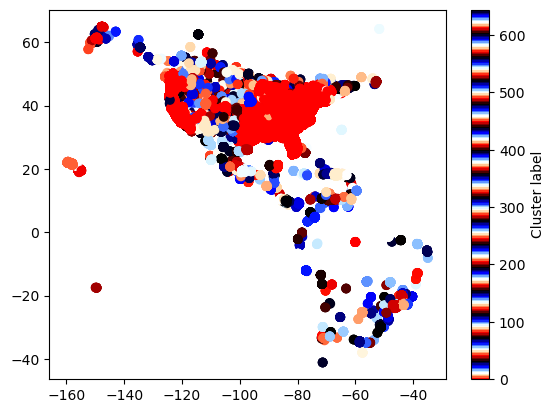

In [41]:
# Plot of NOT noise clusters
# Perhaps we should plot by smaller areas in this case.
scatter = plt.scatter(df_left_unique_id['longitude'][df_left_unique_id["final_labels"] != -1], 
                      df_left_unique_id['latitude'][df_left_unique_id["final_labels"] != -1], 
                      c=df_left_unique_id["final_labels"][df_left_unique_id["final_labels"] != -1], cmap="flag") # cmap="tab20b"

plt.colorbar(scatter, label='Cluster label')

x_limits = plt.gca().get_xlim()
y_limits = plt.gca().get_ylim()

(-46.44254713503501, 70.262983968335)

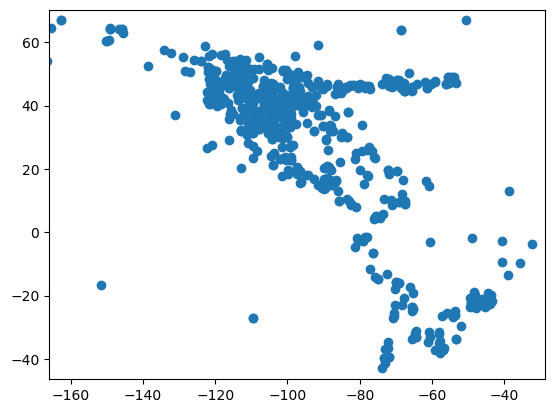

In [42]:
# Plotting noise:
lable_choice = -1  # label you want to plot

scatter = plt.scatter(df_left_unique_id['longitude'][df_left_unique_id["final_labels"] == lable_choice], 
                      df_left_unique_id['latitude'][df_left_unique_id["final_labels"] == lable_choice])
                    #c=df_left_unique_id["final_labels"][df_left_unique_id["final_labels"] == lable_choice]) # cmap="tab20b"

plt.xlim(x_limits)
plt.ylim(y_limits)

We still get a lot of clusters. Some of them seem sensible, for example, 0 and 1 as seen below. Yet there are lot of clusters that look as if they should be a single one, for example the black cluster at (-120, 40) that is surouned by a single red cluster (plotted below with label 1). More interestingly is the noise map: a lot of points that are noise look as if they were to falsely marked noise, as seen in the above noise plot.

(-46.44254713503501, 70.262983968335)

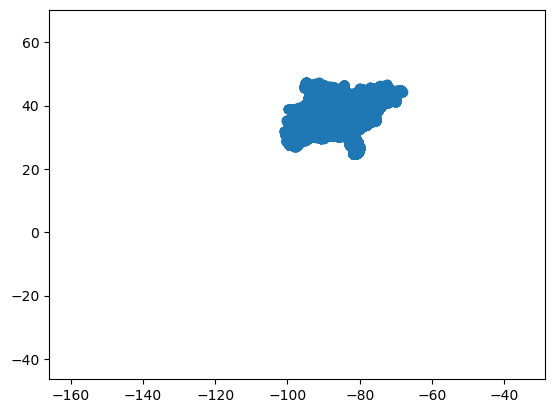

In [43]:
lable_choice = 0  # label you want to plot

scatter = plt.scatter(df_left_unique_id['longitude'][df_left_unique_id["final_labels"] == lable_choice], 
                      df_left_unique_id['latitude'][df_left_unique_id["final_labels"] == lable_choice])
                    #c=df_left_unique_id["final_labels"][df_left_unique_id["final_labels"] == lable_choice]) # cmap="tab20b"

plt.xlim(x_limits)
plt.ylim(y_limits)

(-46.44254713503501, 70.262983968335)

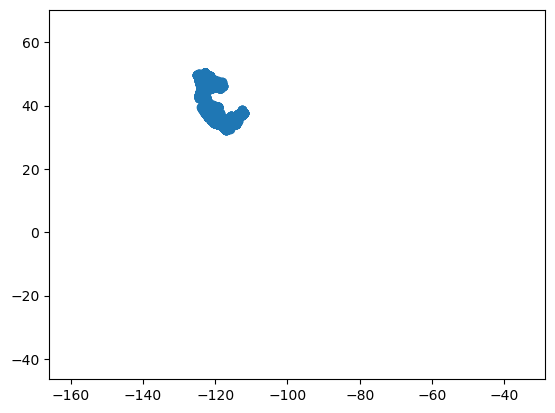

In [44]:
lable_choice = 1  # label you want to plot

scatter = plt.scatter(df_left_unique_id['longitude'][df_left_unique_id["final_labels"] == lable_choice], 
                      df_left_unique_id['latitude'][df_left_unique_id["final_labels"] == lable_choice])
                    #c=df_left_unique_id["final_labels"][df_left_unique_id["final_labels"] == lable_choice]) # cmap="tab20b"

plt.xlim(x_limits)
plt.ylim(y_limits)

Let's try with epsilon = 1. This time we'll need to split up the world into more pieces due to memmory limitations:

In [45]:
# We split the area into two with chosen epsilon
epsilon = 1

# Splitting the left side into two manageable reagions. The machine that ran the code could handle 160k points but not much more for this epsilon.
df_1 = df_left_unique_id[df_left_unique_id["longitude"] <= -120 + epsilon*1/2][["latitude", "longitude"]] 
df_2 = df_left_unique_id[(df_left_unique_id["longitude"] >= -120 - epsilon *1/2) & (df_left_unique_id["longitude"] <= -105 + epsilon *1/2)][["latitude", "longitude"]] 
df_3 = df_left_unique_id[(df_left_unique_id["longitude"] >= -105 - epsilon *1/2) & (df_left_unique_id["longitude"] <= -95 + epsilon *1/2)][["latitude", "longitude"]] 
df_4 = df_left_unique_id[(df_left_unique_id["longitude"] >= -95 - epsilon *1/2) & (df_left_unique_id["longitude"] <= -85 + epsilon *1/2)][["latitude", "longitude"]] 
df_5 = df_left_unique_id[(df_left_unique_id["longitude"] >= -85 - epsilon *1/2) & (df_left_unique_id["longitude"] <= -78 + epsilon *1/2)][["latitude", "longitude"]] 
df_6 = df_left_unique_id[(df_left_unique_id["longitude"] >= -78 - epsilon *1/2)][["latitude", "longitude"]] 

# We choose a smaller overalp to further decrease on points. Furthermoe epsilon 1 is a large radius.

print(len(df_1), "points in 1")
print(len(df_2), "points in 2")
print(len(df_3), "points in 3")
print(len(df_4), "points in 4")
print(len(df_5), "points in 5")
print(len(df_6), "points in 6")


102709 points in 1
110920 points in 2
140999 points in 3
132273 points in 4
140630 points in 5
135461 points in 6


In [46]:
# Clustering and merging regions
labels_1, core_samples_1 = DBSCAN_clusterin(df_1, epsilon, min_points = 3)

21 clusters not incl noise
15 points of noise
0.01 % of data is noise


In [47]:
labels_2, core_samples_2 = DBSCAN_clusterin(df_2, epsilon, min_points = 3)

28 clusters not incl noise
14 points of noise
0.01 % of data is noise


In [48]:
push_2 = len(set(labels_1))
push_3 = len(set(labels_2)) + push_2
mappings, labels_right = create_mapping(df_1, labels_1, core_samples_1, df_2, labels_2, core_samples_2, push = push_2 )
new_1, new_2 = merge_labels(labels_1, labels_right, mappings)

4988  num of shared points


In [49]:
labels_3, core_samples_3 = DBSCAN_clusterin(df_3, epsilon, min_points = 3)

15 clusters not incl noise
15 points of noise
0.01 % of data is noise


In [50]:
mappings, labels_right = create_mapping(df_2, new_2, core_samples_2, df_3, labels_3, core_samples_3, push = push_3)
new_2, new_3 = merge_labels(new_2, labels_right, mappings)

10139  num of shared points


In [51]:
labels_4, core_samples_4 = DBSCAN_clusterin(df_4, epsilon, min_points = 3)

8 clusters not incl noise
6 points of noise
0.0 % of data is noise


In [52]:
push_4 =  len(set(labels_3)) + push_3
mappings, labels_right = create_mapping(df_3, new_3, core_samples_3, df_4, labels_4, core_samples_4, push = push_4)
new_3, new_4 = merge_labels(new_3, labels_right, mappings)

19589  num of shared points


In [53]:
labels_5, core_samples_5 = DBSCAN_clusterin(df_5, epsilon, min_points = 3)

13 clusters not incl noise
5 points of noise
0.0 % of data is noise


In [54]:
push_5 =  len(set(labels_4)) + push_4
mappings, labels_right = create_mapping(df_4, new_4, core_samples_4, df_5, labels_5, core_samples_5, push = push_5)
new_4, new_5 = merge_labels(new_4, labels_right, mappings)

10167  num of shared points


In [55]:
labels_6, core_samples_6 = DBSCAN_clusterin(df_6, epsilon, min_points = 3)

86 clusters not incl noise
49 points of noise
0.04 % of data is noise


In [56]:
push_6 =  len(set(labels_5)) + push_5
mappings, labels_right = create_mapping(df_5, new_5, core_samples_5, df_6, labels_6, core_samples_6, push = push_6)
new_5, new_6 = merge_labels(new_5, labels_right, mappings)

6008  num of shared points


In [57]:
# Merging into one label list. 

df_left_unique_id["final_labels"] = -1

df_1['labels'] = new_1
df_2['labels'] = new_2
df_3['labels'] = new_3
df_4['labels'] = new_4
df_5['labels'] = new_5
df_6['labels'] = new_6


# replace with new label if new label is not -1
df_left_unique_id.loc[df_1[df_1["labels"] != -1].index, "final_labels"] =  [x for x in new_1 if x != -1]
df_left_unique_id.loc[df_2[df_2["labels"] != -1].index, "final_labels"] = [x for x in new_2 if x != -1]
df_left_unique_id.loc[df_3[df_3["labels"] != -1].index, "final_labels"] = [x for x in new_3 if x != -1]
df_left_unique_id.loc[df_4[df_4["labels"] != -1].index, "final_labels"] = [x for x in new_4 if x != -1]
df_left_unique_id.loc[df_5[df_5["labels"] != -1].index, "final_labels"] = [x for x in new_5 if x != -1]
df_left_unique_id.loc[df_6[df_6["labels"] != -1].index, "final_labels"] = [x for x in new_6 if x != -1]

# Have to do it this way because indexes come from the orignal 6mln item data set. 

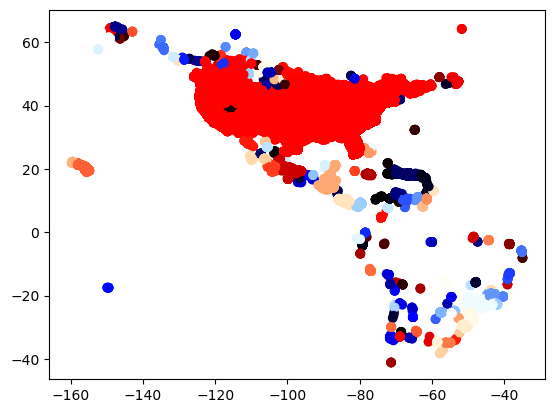

In [58]:
# Plot of NOT noise clusters
scatter = plt.scatter(df_left_unique_id['longitude'][df_left_unique_id["final_labels"] != -1], 
                      df_left_unique_id['latitude'][df_left_unique_id["final_labels"] != -1], 
                      c=df_left_unique_id["final_labels"][df_left_unique_id["final_labels"] != -1], cmap="flag", alpha = 1)

#plt.colorbar(scatter, label='Cluster label')

x_limits = plt.gca().get_xlim()
y_limits = plt.gca().get_ylim()

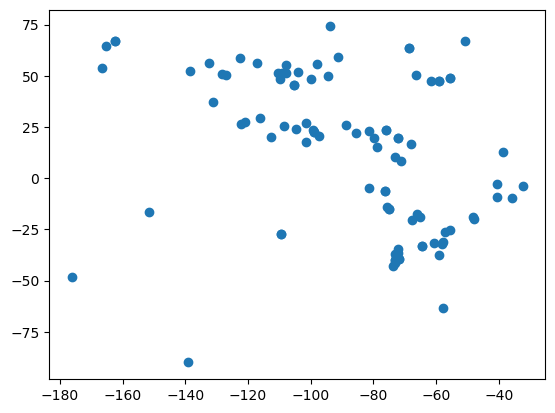

In [59]:
# Plotting noise:
lable_choice = -1  # label you want to plot

scatter = plt.scatter(df_left_unique_id['longitude'][df_left_unique_id["final_labels"] == lable_choice], 
                      df_left_unique_id['latitude'][df_left_unique_id["final_labels"] == lable_choice])
                    #c=df_left_unique_id["final_labels"][df_left_unique_id["final_labels"] == lable_choice]) # cmap="tab20b"

#plt.xlim(x_limits)
#plt.ylim(y_limits)

The noise plot seems to look more realistic yet we see in south america an noise clustering around (-75, -37) which looks almost like a cluster. Furthermore, USA is primarily one giant cluster which does not allow us to infer anything special. Thys clearly for USA epsilon = 1 is too large. Yet it seems cluster more sensibly for the caribbean area. Thus it is likely that due to the difference of distributions DBScan will give bad clustreing in at least one region for any chosen epsilon (for epsilon we get too much noise, for large - densne regions become a single uninfromative cluster). Furthermore in this case we have no heuristics as how to choose epsilon.

Furthermore, this gives ideas on what could work better for location clustering, for example, picking a method that does not require a single choice of epsilon. Another avenue is including the frequency of visits to a single place as an extra dimension. The idea behind this would be that even if we have 3 locations near to each other they are likely to be noise if they very few total visits. On the other hand a location with a lot of visits probably should not be marked as noise even if it is fairly isolated.


2.2.2 OPTICS

In our initial experimentation of OPTICS, an hierarchical clustering algortihm we have studied in class, we decided to focus on Europe to get meaningful clusterings. This will still allow for OPTICS to still showcase its proficiency in being able to cluster areas of different densities.

In [3]:
eu_df = df[
    (df["latitude"] >= 35) & (df["latitude"] <= 71) &
    (df["longitude"] >= -10) & (df["longitude"] <= 40)
]

print("Europe total points:", len(eu_df))

eu_sample = eu_df.sample(
    n=min(100_000, len(eu_df)),
    random_state=42
).copy()

print("Europe sampled:", len(eu_sample))

eu_coords = np.radians(eu_sample[["latitude", "longitude"]].values)

Europe total points: 2199881
Europe sampled: 100000


Using the k-distance plot in algorithms like DBSCAN helps us to identify a good estimate for the algorithms parameters. In OPTICS, this method yields a sound starting point if one wants to use max_eps parameter to have a reasonable computation time. Experimenting with the parameter, we determined that leaving the max_eps to be default i.e. having no limitation the maximum possible radius of the neighbourhood works best, still achieving a modest runtime.

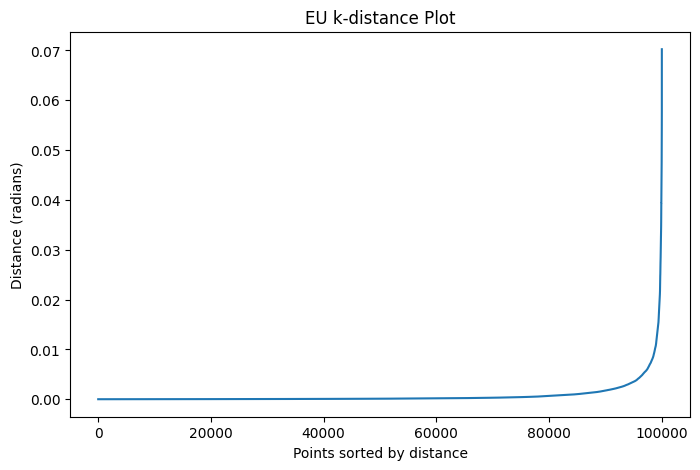

Example elbow in km: 11.122667195351287


In [4]:
k = 20

nbrs = NearestNeighbors(n_neighbors=k, metric="haversine")
nbrs.fit(eu_coords)

distances, _ = nbrs.kneighbors(eu_coords)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.title("EU k-distance Plot")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance (radians)")
plt.show()

earth_radius_km = 6371
print("Example elbow in km:", k_distances[int(len(k_distances)*0.9)] * earth_radius_km)

In [5]:

optics_eu = OPTICS(
    min_samples=200,
    #max_eps= upon testing, default value works well
    metric="haversine",
    cluster_method="xi",
    xi=0.05
)

optics_eu.fit(eu_coords)

labels_la = optics_eu.labels_

/Users/bora/Data-Mining/.venv/lib/python3.13/site-packages/sklearn/cluster/_optics.py:1084: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


Reachability plot is one of the key features of OPTICS as it gives another metric to determine how well the clustering algorithm worked. The valleys in the plot indicate clusters, and the algorithm even uncovers the hierarchical clusters within the data to be more easily seen from the plot itself. Here it seems taking Europe as the area of interest makes it difficult for the reachability plot to be analyzed.

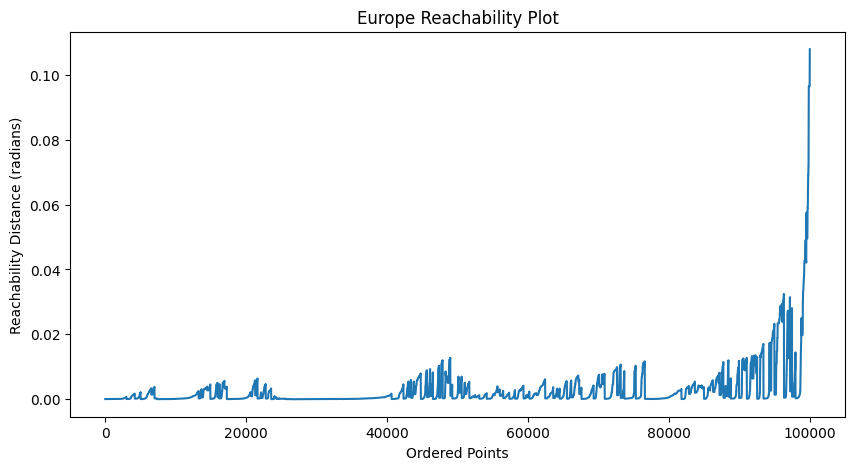

In [6]:
reachability = optics_eu.reachability_[optics_eu.ordering_]

plt.figure(figsize=(10,5))
plt.plot(reachability)
plt.title("Europe Reachability Plot")
plt.xlabel("Ordered Points")
plt.ylabel("Reachability Distance (radians)")
plt.show()

In [7]:
# major European cities (lat, lon)
cities = {
    "London": (51.5074, -0.1278),
    "Paris": (48.8566, 2.3522),
    "Berlin": (52.5200, 13.4050),
    "Madrid": (40.4168, -3.7038),
    "Rome": (41.9028, 12.4964),
    "Amsterdam": (52.3676, 4.9041),
    "Brussels": (50.8503, 4.3517),
    "Vienna": (48.2082, 16.3738),
    "Prague": (50.0755, 14.4378),
    "Copenhagen": (55.6761, 12.5683),
    "Stockholm": (59.3293, 18.0686),
    "Oslo": (59.9139, 10.7522),
    "Helsinki": (60.1699, 24.9384),
    "Budapest": (47.4979, 19.0402),
    "Milan": (45.4642, 9.1900),
    "Barcelona": (41.3851, 2.1734),
    "Venice": (45.4408, 12.3155),
    "Edinburgh": (55.9533, -3.1883),
    "Manchester": (53.4808, -2.2426),
    "Lisbon": (38.7223, -9.1393),
}

Since our dataset lacks a ground truth in this geographical clustering step, alongside interpreting the clusters visually we decided to include some major European cities where we anticipate some clusters to form around. This helped us in playing around the parameters and finding a good middle spot where the output clustering was most meaningful.

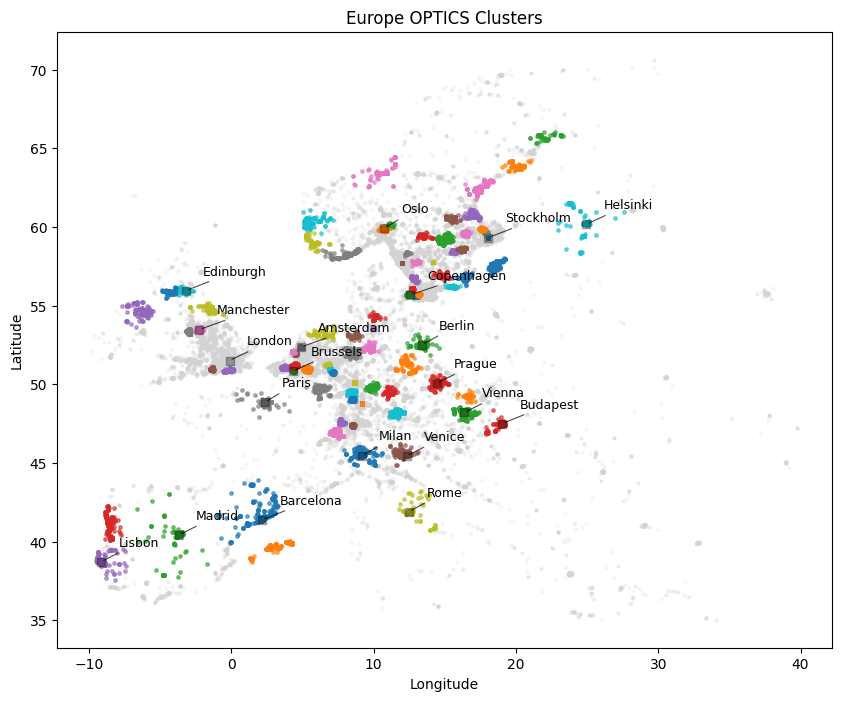

In [8]:
eu_sample["cluster"] = optics_eu.labels_
unique_labels = set(optics_eu.labels_)

plt.figure(figsize=(10,8))

noise_mask = eu_sample["cluster"] == -1
plt.scatter(
    eu_sample[noise_mask]["longitude"],
    eu_sample[noise_mask]["latitude"],
    s=4,
    c="lightgray",
    alpha=0.15,
    label="Noise"
)

# clusters
for label in unique_labels:
    if label == -1:
        continue
        
    mask = eu_sample["cluster"] == label
    
    plt.scatter(
        eu_sample[mask]["longitude"],
        eu_sample[mask]["latitude"],
        s=6,
        alpha=0.6
    )

# plot major cities
for city, (lat, lon) in cities.items():

    plt.scatter(
        lon,
        lat,
        marker="s",
        s=30,
        c="black",
        alpha=0.3,
        zorder=5
    )

    plt.annotate(
        city,
        xy=(lon, lat),               
        xytext=(lon + 1.2, lat + 1.0), 
        textcoords='data',
        fontsize=9,
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.8,
            alpha=0.7
        )
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Europe OPTICS Clusters")
plt.show()

In [9]:
labels = optics_eu.labels_

# number of clusters (excluding noise)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# number of noise points
n_noise = np.sum(labels == -1)

print("Clusters:", n_clusters)
print("Noise points:", n_noise)
print("Noise ratio:", n_noise / len(labels))

cluster_sizes = pd.Series(labels).value_counts()
cluster_sizes = cluster_sizes[cluster_sizes.index != -1]
print(cluster_sizes.describe())

Clusters: 85
Noise points: 55280
Noise ratio: 0.5528
count      85.000000
mean      526.117647
std       470.005228
min       203.000000
25%       274.000000
50%       418.000000
75%       564.000000
max      3282.000000
Name: count, dtype: float64


With all that being said, clustering European checkin locations did not work perfectly with OPTICS. It seems that even with its capability to capture underlying hierarchical structure, it failed to really capture a clustering that displayed a variety of clusters of different densities with the mass scale of the geographical data covering all of Europe.

For further experimentation, we decided to focus down on a smaller metropolitan area, this time Los Angeles. Our dataset also gives us location IDs which lets us narrow down onto unique location entries.

In [10]:
locations = df[["location_id", "latitude", "longitude"]].drop_duplicates("location_id")

print("Unique locations:", len(locations))

la_locations = locations[
    (locations["latitude"] >= 33.5) & (locations["latitude"] <= 34.5) &
    (locations["longitude"] >= -119) & (locations["longitude"] <= -117)
]

print("LA locations:", len(la_locations))

Unique locations: 1280969
LA locations: 40181


In [11]:
la_sample = la_locations.sample(
    n=min(100_000, len(la_locations)),
    random_state=42
).copy()

coords = np.radians(la_sample[["latitude", "longitude"]].values)

In [12]:
max_eps_km = 5
max_eps_rad = max_eps_km / 6371

optics = OPTICS(
    min_samples=30,
    max_eps=max_eps_rad,
    metric="haversine",
    cluster_method="xi",
    xi=0.05
)

labels = optics.fit_predict(coords)

la_sample["cluster"] = labels

As it can be seen in the reachability plot below, this finer focus onto a location like LA gave us a better reachability plot where clusters can be more easily inspected visually from the plot. This result gives us good motivation to consider areas of this scale as well as the usage of unique location IDs. 

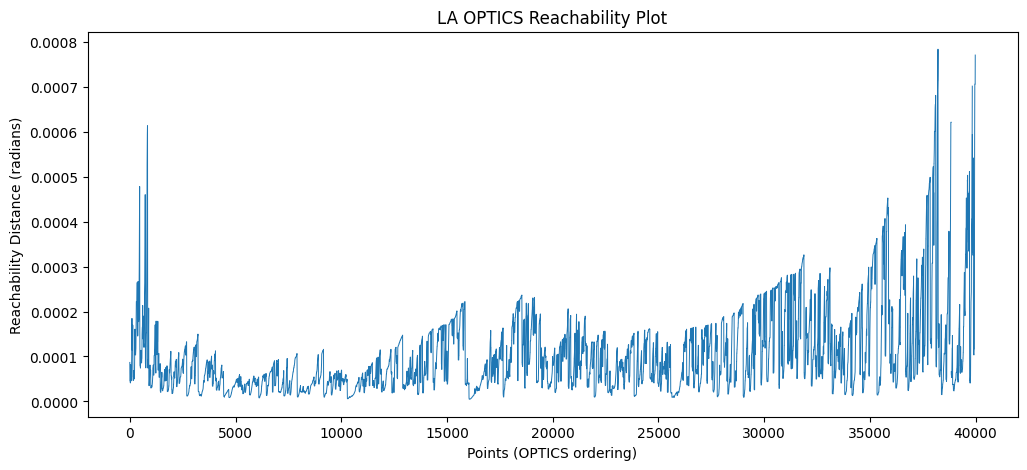

In [13]:
reachability = optics.reachability_[optics.ordering_]

plt.figure(figsize=(12,5))

plt.plot(reachability, linewidth=0.7)

plt.title("LA OPTICS Reachability Plot")
plt.xlabel("Points (OPTICS ordering)")
plt.ylabel("Reachability Distance (radians)")

plt.show()

In [14]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("Clusters:", n_clusters)
print("Noise points:", n_noise)
print("Noise ratio:", n_noise / len(labels))

cluster_sizes = pd.Series(labels).value_counts()
cluster_sizes = cluster_sizes[cluster_sizes.index != -1]

print(cluster_sizes.describe())

Clusters: 314
Noise points: 20995
Noise ratio: 0.52251063935691
count    314.000000
mean      61.101911
std       29.501001
min       30.000000
25%       41.000000
50%       52.000000
75%       73.000000
max      270.000000
Name: count, dtype: float64


/var/folders/6s/3sdb8sf50bb83t6c0zml346m0000gn/T/ipykernel_34661/3350519167.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", max(n_clusters, 1))


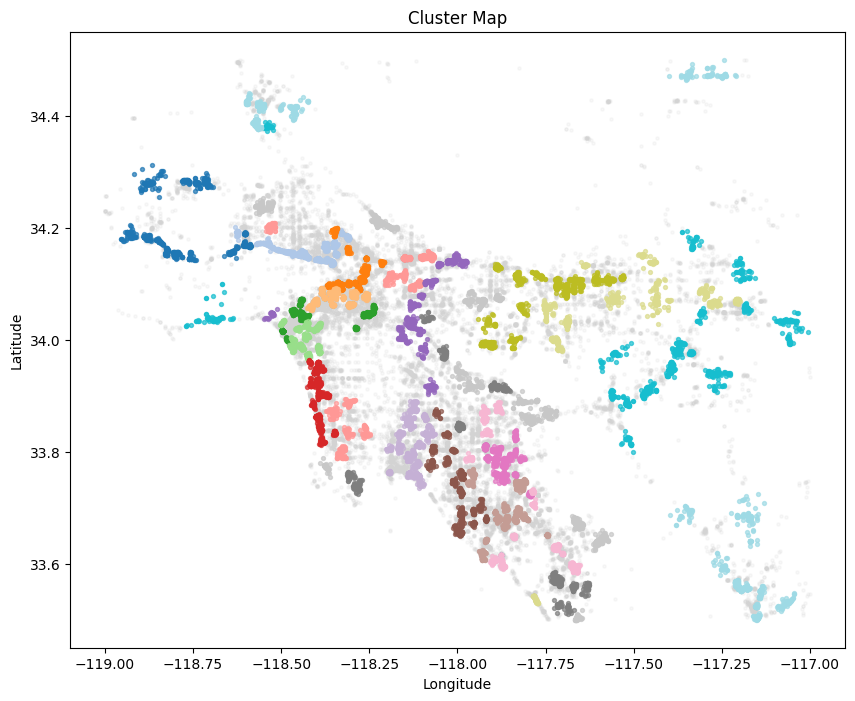

In [15]:
labels = la_sample["cluster"].values

unique_clusters = sorted([c for c in np.unique(labels) if c != -1])
n_clusters = len(unique_clusters)

# assign colors to clusters
cmap = cm.get_cmap("tab20", max(n_clusters, 1))
cluster_color_map = {cluster: cmap(i) for i, cluster in enumerate(unique_clusters)}

plt.figure(figsize=(10,8))

# plot noise first
noise_mask = labels == -1
plt.scatter(
    la_sample.loc[noise_mask, "longitude"],
    la_sample.loc[noise_mask, "latitude"],
    c="lightgray",
    s=5,
    alpha=0.15,
    label="Noise"
)

# plot clusters
for cluster in unique_clusters:
    
    mask = labels == cluster
    
    plt.scatter(
        la_sample.loc[mask, "longitude"],
        la_sample.loc[mask, "latitude"],
        color=cluster_color_map[cluster],
        s=8,
        alpha=0.7
    )

plt.title("Cluster Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

if n_clusters <= 15:
    plt.legend()

plt.show()

The narrowed down focus and the usage of the unique locations definitely helped the quality of the clustering, however still the amount of noise labelled in the data being slightly over 50% of the entire locations signals some concerns for how well OPTICS is performing for this dataset.

2.2.3 Agglomerative Clustering

The next clustering algorithm we will be analysing is Agglomerative Clustering. Since we are working with geospatial data this means that our data has an inherently hierarchical structure: neighbourhoods, cities, and countries. Thus, agglomerative clustering seems like a natural fit for an algorithm that could work well within these hierarchies as well as model real boundaries of cities. We will start off with examining our main two focus points, the US and Europe. We will be working with samples made out of 50000 points due to technical limitations and memory issues.

In [60]:
BASE_DIR = Path().resolve()
file_path = BASE_DIR / "data" / "loc-gowalla-preproc.csv"
df_cluster = pd.read_csv(file_path)

Text(0, 0.5, 'Latitude')

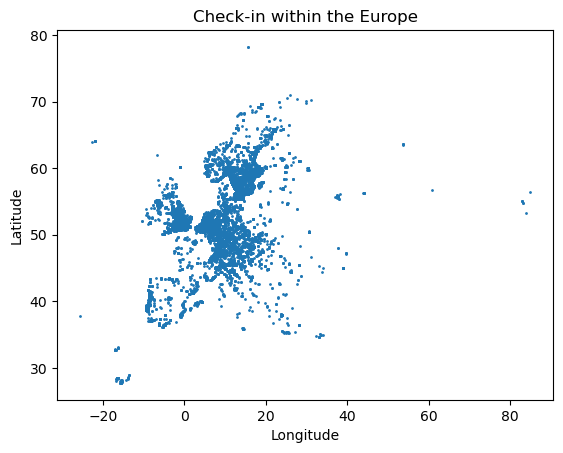

In [61]:
df_eu = df_cluster[df_cluster["continent"] == "Europe"].copy()
df_eu_sample = df_eu.sample(50_000, random_state=42)

plt.scatter(df_eu_sample["longitude"], df_eu_sample["latitude"], s=1)
plt.title("Check-in within the Europe")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

Text(0, 0.5, 'Latitude')

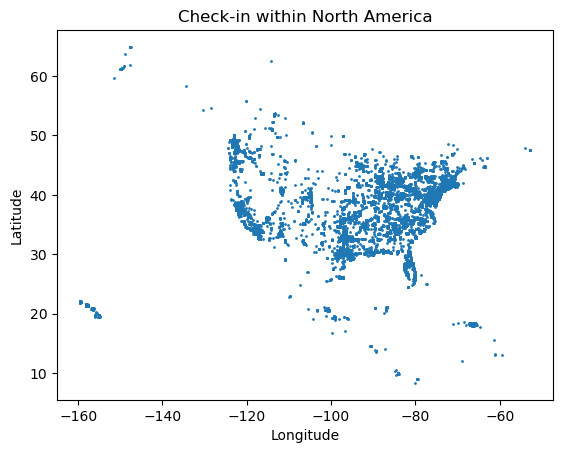

In [62]:
df_na = df_cluster[df_cluster["continent"] == "North America"].copy()
df_na_sample = df_na.sample(50_000, random_state=42)

plt.scatter(df_na_sample["longitude"], df_na_sample["latitude"], s=1)
plt.title("Check-in within North America")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

The agglomerative clustering function takes as input the data frame and performs the clustering algorithm and plots the results. In this way we will analyze and perform the hierarchical clustering on a few different scales, starting from the continents themselves, then taking by country/state and finally by city. 

In [63]:
def agglomerative_cluster(df, n_clusters=10, title="Agglomerative Clustering"):
    X = df[["latitude", "longitude"]].values
    X_scaled = StandardScaler().fit_transform(X)

    labels = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(X_scaled)

    df_plot = df.copy()
    df_plot["cluster"] = labels

    plt.figure(figsize=(10, 8))
    plt.scatter(
        df_plot["longitude"], df_plot["latitude"],
        c=df_plot["cluster"], cmap="tab20", s=2, alpha=0.6
    )
    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()
    
    return df_plot

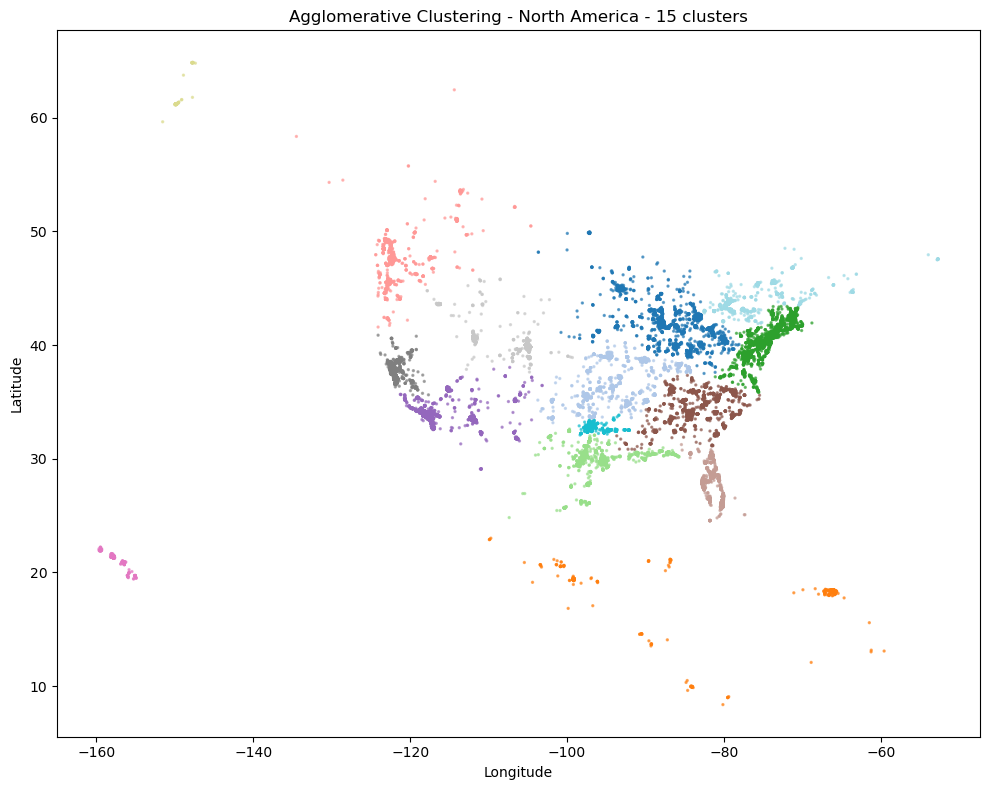

,user_id,checkin_time,latitude,longitude,location_id,city,country_code,country_name,continent,cluster
3306868,44394,2010-07-05 15:10:44+00:00,32.722576,-97.356774,369505,Fort Worth,us,United States,North America,13
281764,898,2010-10-21 01:41:10+00:00,37.323592,-121.935024,85908,Burbank,us,United States,North America,10
141002,458,2010-02-25 19:06:17+00:00,34.051379,-118.256632,345963,Los Angeles,us,United States,North America,6
5281867,118624,2010-01-17 15:10:45+00:00,39.020773,-94.838268,401469,Edwardsville,us,United States,North America,1
623205,2646,2010-06-27 18:10:00+00:00,29.742455,-95.411298,83062,West University Place,us,United States,North America,4
...,...,...,...,...,...,...,...,...,...,...
1181047,5654,2010-08-17 01:25:02+00:00,30.265736,-97.737913,444277,Austin,us,United States,North America,4
295870,948,2010-07-15 02:43:51+00:00,42.524375,-88.985084,1366283,Beloit,us,United States,North America,0
550310,2237,2010-08-14 19:50:49+00:00,33.813949,-117.924692,67957,Anaheim,us,United States,North America,6
4313798,90292,2010-04-19 00:13:25+00:00,30.162355,-97.790540,3475086,Onion Creek,us,United States,North America,4


In [64]:
agglomerative_cluster(df_na_sample, 15, "Agglomerative Clustering - North America - 15 clusters")

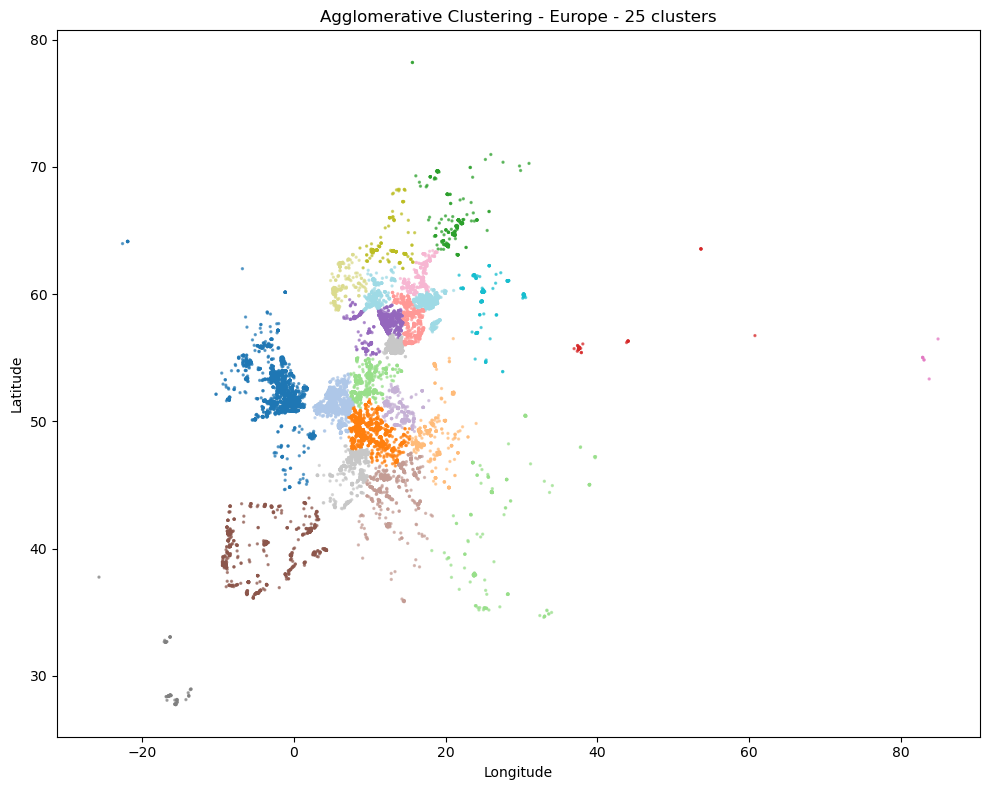

,user_id,checkin_time,latitude,longitude,location_id,city,country_code,country_name,continent,cluster
2348902,21796,2010-09-19 07:31:30+00:00,59.332024,18.055719,79394,Stockholm,se,Sweden,Europe,23
3867240,63146,2010-01-30 12:47:33+00:00,55.689085,13.220179,103171,Lund,se,Sweden,Europe,18
4248373,87092,2010-08-09 13:40:43+00:00,59.331170,18.042193,425819,Stockholm,se,Sweden,Europe,23
2992699,38404,2010-04-06 05:20:35+00:00,59.927308,10.731615,277191,Oslo,no,Norway,Europe,24
4855366,107553,2010-07-02 19:38:51+00:00,62.047741,17.248329,1374392,Bergsjoe,se,Sweden,Europe,16
...,...,...,...,...,...,...,...,...,...,...
1204900,5864,2009-12-23 14:04:03+00:00,55.716028,13.179957,58891,Lund,se,Sweden,Europe,18
2971283,38201,2010-05-05 10:36:35+00:00,52.069979,5.178071,45094,Bunnik,nl,Netherlands,Europe,2
4280608,89035,2010-08-08 08:46:00+00:00,51.499126,-0.298058,30385,Ealing,gb,United Kingdom,Europe,0
4259520,87690,2010-03-24 15:40:19+00:00,56.674450,12.856450,282285,Halmstad,se,Sweden,Europe,18


In [65]:
agglomerative_cluster(df_eu_sample, 25, "Agglomerative Clustering - Europe - 25 clusters")

After experimentation with the cluster numbers for both the North America and Europe regions, clusters of sizes 15 and 25, respectively, were picked. It can already be observed the forming of big metropolitan areas. When looking at North America, the biggest clusters correspond with the most dense areas, so California on the west coast and NYC on the east coast. The Chicago area is also easily identifiable as a big cluster, as is Florida as a separate one. A very clear and easy distinction can be made between the states, and of course the biggest hubs are on the coast versus the sparsity inland. In the major inland areas, there are large empty spatial gaps between clusters corresponding with just sparsely populated areas where deserts and prairies are located.

Similar observations can be made when looking at Europe. European cities are more tightly packed, and so are the clusters; thus, more clusters are necessary in order to capture better boundaries of countries. Immediately a big cluster jumps out, the UK London area, as a big metropolitan area, following Paris and Berlin. In the centre the distinction between countries is clearer; for example, Spain is easily distinguishable as one big cluster, as is the UK. There is also a small separation observable between the boundaries of Germany and the Netherlands. Sparser areas of population, however, have more multiple small clusters, observed very well in the Scandinavian area. When looking at Sweden, it is a very big territory with less population density; thus, we can see it being separated into multiple smaller clusters in comparison with the UK, a small area with large population density, being grouped as one big cluster.

Next, we will examine a smaller scale and verify if similar patterns emerge. For this purpose, we will look at the UK and Sweden in Europe.

Text(0, 0.5, 'Latitude')

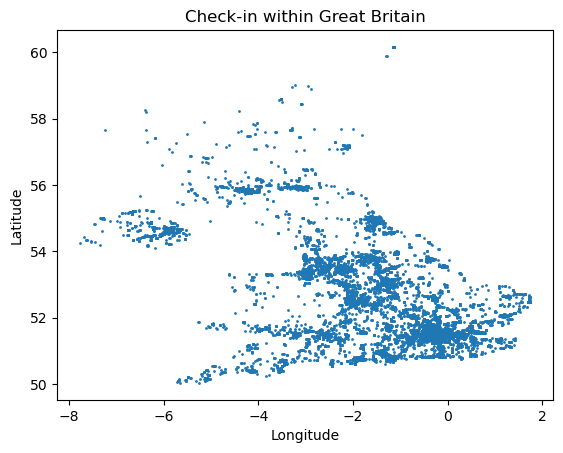

In [66]:
df_gb = df_cluster[df_cluster["country_code"] == "gb"].copy()
df_gb_sample = df_gb.sample(50_000, random_state=42)

plt.scatter(df_gb_sample["longitude"], df_gb_sample["latitude"], s=1)
plt.title("Check-in within Great Britain")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

Text(0, 0.5, 'Latitude')

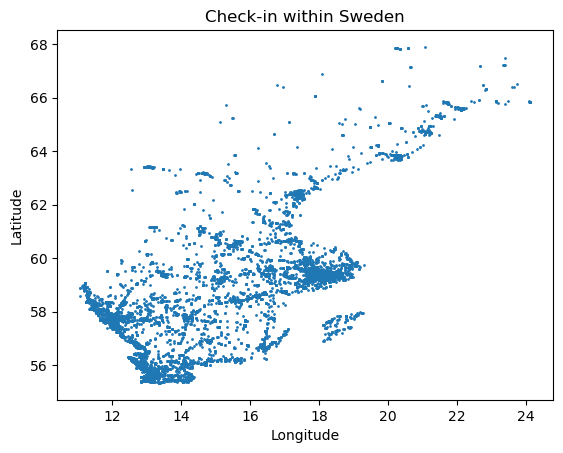

In [67]:
df_se = df_cluster[df_cluster["country_code"] == "se"].copy()
df_se_sample = df_se.sample(50_000, random_state=42)

plt.scatter(df_se_sample["longitude"], df_se_sample["latitude"], s=1)
plt.title("Check-in within Sweden")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

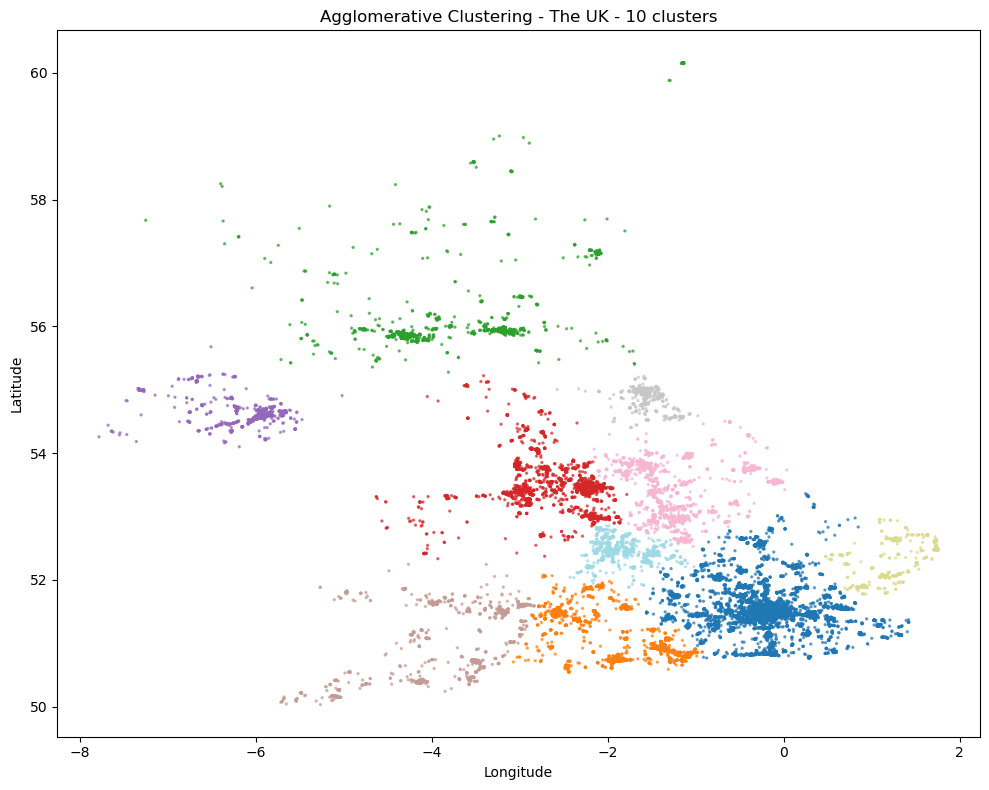

,user_id,checkin_time,latitude,longitude,location_id,city,country_code,country_name,continent,cluster
3496789,49352,2010-07-21 12:34:30+00:00,51.802264,-0.194523,666188,Welwyn Garden City,gb,United Kingdom,Europe,0
4614158,103183,2010-08-28 21:24:15+00:00,53.721233,-1.865050,1255579,Halifax,gb,United Kingdom,Europe,6
5347377,120763,2010-02-04 09:49:07+00:00,53.794425,-1.543078,263293,Leeds,gb,United Kingdom,Europe,6
971749,4508,2010-08-31 13:10:57+00:00,51.061968,-1.311463,1527091,Winchester,gb,United Kingdom,Europe,1
2993227,38409,2010-04-06 07:28:50+00:00,51.528589,-0.132156,858505,Camden Town,gb,United Kingdom,Europe,0
...,...,...,...,...,...,...,...,...,...,...
1914134,15507,2010-07-22 09:05:34+00:00,51.494504,-0.274658,762275,Acton,gb,United Kingdom,Europe,0
2502539,26185,2009-12-15 11:15:34+00:00,55.832987,-4.428788,186917,Paisley,gb,United Kingdom,Europe,2
5065684,111971,2010-05-23 12:31:34+00:00,51.597272,-2.981621,883463,Newport,gb,United Kingdom,Europe,5
3587945,51792,2010-02-17 11:00:42+00:00,50.788457,-1.082536,465712,Southsea,gb,United Kingdom,Europe,1


In [68]:
agglomerative_cluster(df_gb_sample, 10, "Agglomerative Clustering - The UK - 10 clusters")

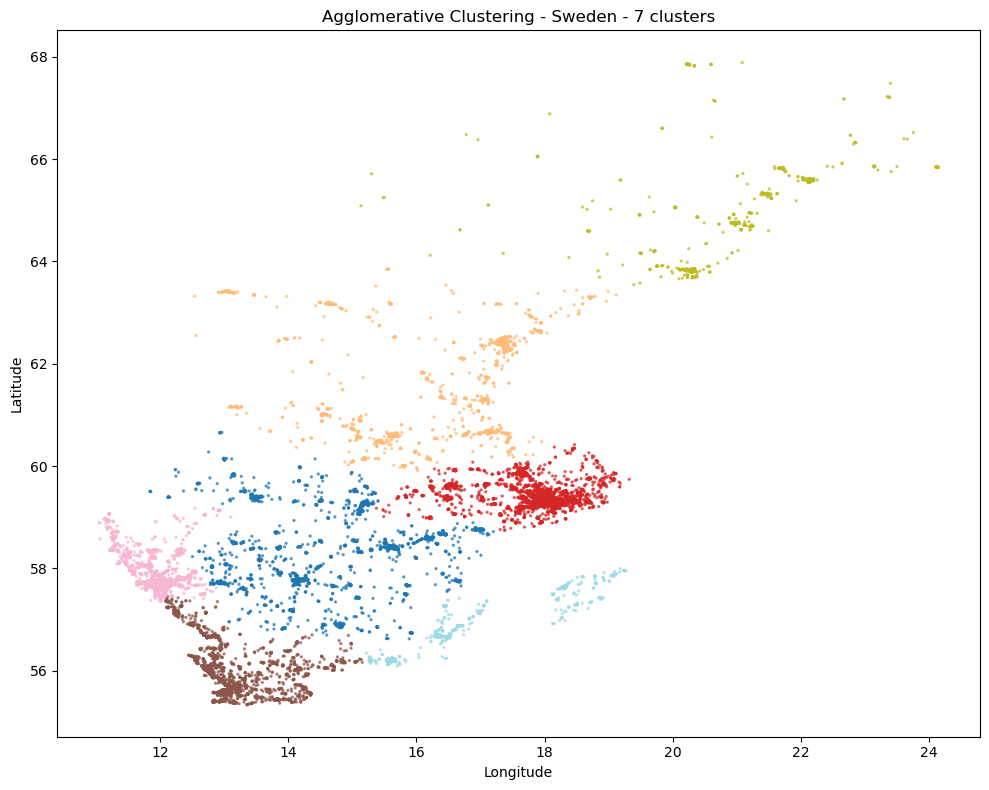

,user_id,checkin_time,latitude,longitude,location_id,city,country_code,country_name,continent,cluster
3670416,54996,2010-01-05 08:52:40+00:00,57.714698,11.966850,124263,Goeteborg,se,Sweden,Europe,4
4865535,107759,2010-09-05 18:26:49+00:00,57.991270,13.090957,1453674,Herrljunga,se,Sweden,Europe,0
5700193,135467,2010-09-26 14:08:03+00:00,57.689243,12.013705,4485402,Moelndal,se,Sweden,Europe,4
6175510,166198,2010-05-19 11:50:26+00:00,59.311474,18.059109,888888,Arsta,se,Sweden,Europe,2
5640444,132335,2010-03-18 10:08:09+00:00,59.299543,18.055290,572819,Arsta,se,Sweden,Europe,2
...,...,...,...,...,...,...,...,...,...,...
4565806,102082,2010-06-24 15:47:36+00:00,55.695680,13.198174,301159,Lund,se,Sweden,Europe,3
6174623,166157,2010-03-07 14:26:06+00:00,59.614513,16.543887,212841,Vasteras,se,Sweden,Europe,2
6021757,153041,2010-03-19 11:53:39+00:00,59.346815,18.059162,322432,Stockholm,se,Sweden,Europe,2
6360152,185792,2010-09-01 09:11:33+00:00,57.686679,11.986091,484011,Goeteborg,se,Sweden,Europe,4


In [69]:
agglomerative_cluster(df_se_sample, 7, "Agglomerative Clustering - Sweden - 7 clusters")

As expected, we see that the biggest clusters of user check-ins correspond clearly to the biggest cities/most populated regions. When looking at the scatterplot of the UK, we see clusters formed around the different regions of the UK: London, the Midlands, Scotland, and Wales. The biggest clusters are represented in central London and Brighton, in the Wales region, Manchester and Liverpool, Scotland is a sparser cluster all on its own; and another major cluster is Northern Ireland.

In contrast, Sweden is a much bigger country by area; however, it has less population density. We identify 3 big clusters, each corresponding to Stockholm, Gothenburg and Malmö. We have a few more clusters in the centre and sparser clusters covering very big areas where there is less population density. 

The UK has more mid-sized cities competing for clusters and thus making the selection of k have a bit more flexibility and allowing a bigger size of clusters, while Sweden has, in big part, 3 major cities where most of the population is concentrated, making the selection of k be more reduced to smaller values to allow for much cleaner results and boundaries.

## 3. Module 2 — Graph-Based Analysis

In [ ]:
import networkx as nx

# Build graph
G = nx.Graph()

## 4. Module 3 — Pattern / Text Mining

In [ ]:
# Pattern mining implementation
patterns = None

## 5. Final Synthesis and Reflection

- Key insights:
- Limitations:
- Revisions after feedback:
